# Decision Tree Pruning and Hyperparameter tuning

Instructor: Amna Mazen

## Imports

In [ ]:
import os

%matplotlib inline
import string
import sys
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("code/.")

#from plotting_functions import *
from sklearn import datasets
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier
#from utils import *

## Decision Tree Pruning

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


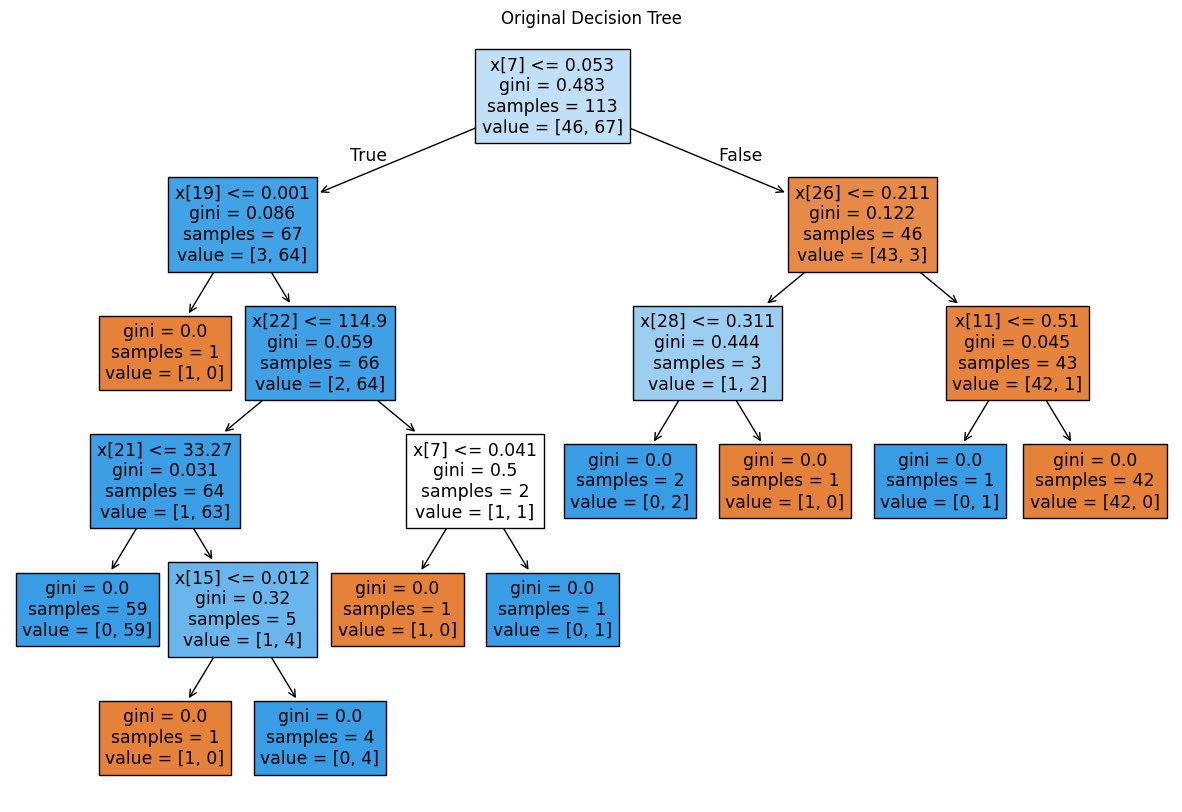

Accuracy before pruning: 0.8881578947368421


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load breast cancer dataset
data = load_breast_cancer()
#X, y = load_breast_cancer(return_X_y=True)
X, y = data.data, data.target

# Get feature names
feature_names = data.feature_names
print("Feature Names:", feature_names)

# Separating Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

# Train decision tree model
model = DecisionTreeClassifier(criterion="gini")
model.fit(X_train, y_train)

# Plot original tree
plt.figure(figsize=(15, 10))
plot_tree(model, filled=True)
plt.title("Original Decision Tree")
plt.show()

# Model Accuracy before pruning
accuracy_before_pruning = model.score(X_test, y_test)
print("Accuracy before pruning:", accuracy_before_pruning)

### Decision Tree Pre-Pruning Implementation

In the implementation, we pruning technique is **hyperparameter tuning** through cross-validation using **GridSearchCV**.

Hyperparameter tuning involves searching for the optimal hyperparameters for a machine learning model to improve its performance.

It does not directly prune the decision tree, but it helps in finding the best combination of hyperparameters, such as **max_depth**, **max_features**, **criterion**, and **splitter**, which indirectly controls the complexity of the decision tree and prevents overfitting. Therefore, it's a form of post-pruning technique.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
parameter = {
    'criterion' :['entropy','gini','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}
# In practice: entropy and log_loss are mathematically equivalent in tree splitting, differing mainly in implementation and interpretation.
#log_loss aligns directly with probabilistic classification objectives used in logistic regression and neural networks.
model = DecisionTreeClassifier()
from sklearn.model_selection import GridSearchCV
cv = GridSearchCV(model,param_grid = parameter,cv = 5) ## 5-Fold Cross validation
cv.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']})

Visualize

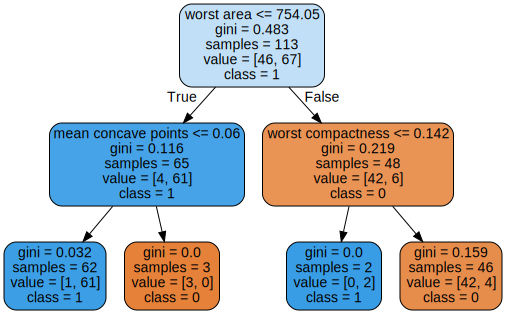

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
best_estimator = cv.best_estimator_

dot_data = export_graphviz(best_estimator, out_file=None, filled=True, rounded=True,feature_names=feature_names, class_names=['0', '1'])
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format='png', cleanup=True)
graph



Best parameters

In [ ]:
accuracy_pre_pruning=cv.score(X_test,y_test)

# Model Accuracy before pruning

print("Accuracy with pre- pruning:", accuracy_pre_pruning)

# Print the best pre-pruning parameters
cv.best_params_

Accuracy with pre- pruning: 0.8947368421052632


{'criterion': 'gini',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

### Decision Tree Post-Pruning Implementation

This line computes the entire pruning path for your already-trained decision tree.


Now **sklearn** calculates all possible effective α (ccp_alpha) values at which the tree structure would change.

It determines which internal nodes can be pruned and at what penalty level.


"Give me all pruning strengths (α values) and the corresponding subtree costs."

In [ ]:
# Cost-complexity pruning (Post-pruning)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
ccp_alphas


array([0.        , 0.00020665, 0.00028932, 0.00051664, 0.00055797,
       0.00055797, 0.00055797, 0.00055797, 0.0005683 , 0.0005683 ,
       0.00057227, 0.00057568, 0.00057863, 0.00057863, 0.00058122,
       0.00058552, 0.00058733, 0.00059178, 0.00059301, 0.00060274,
       0.00060555, 0.00060927, 0.00060991, 0.00061337, 0.00061996,
       0.00062805, 0.00082662, 0.00082662, 0.00082662, 0.00082662,
       0.00082662, 0.00082662, 0.00082662, 0.00082662, 0.00082662,
       0.00089304, 0.00091304, 0.00091882, 0.00092994, 0.00092994,
       0.00092994, 0.00092994, 0.00092994, 0.00092994, 0.00092994,
       0.00092994, 0.00094471, 0.00097229, 0.00098407, 0.00099194,
       0.00099194, 0.00099194, 0.00099194, 0.00101261, 0.00101448,
       0.00103327, 0.00103327, 0.00103327, 0.00103327, 0.00104415,
       0.00104527, 0.0010572 , 0.00106974, 0.00107632, 0.00108065,
       0.00108493, 0.00108718, 0.00110216, 0.00110216, 0.00110216,
       0.00110216, 0.00111318, 0.00111593, 0.00111593, 0.00111

In [ ]:
impurities

array([0.00061996, 0.00082662, 0.00111593, 0.0021492 , 0.00326514,
       0.00438107, 0.005497  , 0.00661294, 0.00774954, 0.00888613,
       0.01003068, 0.01118204, 0.0123393 , 0.01465383, 0.01581626,
       0.0169873 , 0.01816197, 0.01934553, 0.02053155, 0.02173703,
       0.02294812, 0.02416667, 0.02782613, 0.02905286, 0.02967282,
       0.03092892, 0.03175554, 0.03258216, 0.03340877, 0.03423539,
       0.03506201, 0.03588863, 0.03671524, 0.03836848, 0.03919509,
       0.04098118, 0.04189421, 0.04281303, 0.04374297, 0.04467292,
       0.04560286, 0.04653281, 0.04746275, 0.0483927 , 0.04932264,
       0.05025258, 0.05119729, 0.05411416, 0.05509823, 0.05609017,
       0.05708211, 0.05807405, 0.05906599, 0.0600786 , 0.06210757,
       0.06314084, 0.06417411, 0.06520738, 0.06624065, 0.0693731 ,
       0.07041837, 0.07147557, 0.07361505, 0.0757677 , 0.07684834,
       0.07793328, 0.07902046, 0.08012261, 0.08122477, 0.08453124,
       0.08563339, 0.08897293, 0.09008886, 0.09120479, 0.09232

In [ ]:
# Train a series of decision trees with different alpha values
pruned_models = []
for ccp_alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(criterion="gini", ccp_alpha=ccp_alpha)
    pruned_model.fit(X_train, y_train)
    pruned_models.append(pruned_model)

# Find the model with the best accuracy on test data
best_accuracy = 0
best_pruned_model = None
for pruned_model in pruned_models:
    accuracy = pruned_model.score(X_test, y_test)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_pruned_model = pruned_model
# Model Accuracy after pruning
accuracy_after_pruning = best_pruned_model.score(X_test, y_test)
print("Accuracy after pruning:", accuracy_after_pruning)

Accuracy after pruning: 0.7351485148514851


## Hyperparameter Tuning Example on Spotify dataset


### Motivation

- Remember that the fundamental goal of supervised machine learning is to generalize beyond what we see in the training examples.
- We have been using data splitting and cross-validation to provide a framework to approximate generalization error.  
- With this framework, we can improve the model's generalization performance by tuning model hyperparameters using cross-validation on the training set.

 Hyperparameters: the problem

- In order to improve the generalization performance, finding the best values for the important hyperparameters of a model is necessary for almost all models and datasets.
- Picking good hyperparameters is important because if we don't do it, we might end up with an underfit or overfit model.

Let's look at an example of tuning `max_depth` of the `DecisionTreeClassifier` on the Spotify dataset.

The **Spotify** dataset contains various audio features extracted from songs on Spotify, which describe musical characteristics and listener-related attributes. These features are commonly used in machine learning tasks such as **music recommendation**, classification, and popularity prediction.

The dataset includes several **numerical features** that represent properties of each track, such as **acousticness, danceability, energy, instrumentalness, liveness, loudness, speechiness, tempo, and valence**. These attributes capture different aspects of the audio signal, including rhythm, intensity, and emotional tone of the music.

The **output** variable in the dataset represents the genre of the song, which **categorizes each track into a specific music genre**. The goal of machine learning models applied to this dataset is typically to predict the genre of a song based on its audio features.

In [ ]:
spotify_df = pd.read_csv("https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/refs/heads/main/Dataset/Lecture_Dataset/spotify.csv", index_col=0)
X_spotify = spotify_df.drop(columns=["target", "song_title", "artist"])
y_spotify = spotify_df["target"]
X_spotify.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286
1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588
2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173
3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230
4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904


In [ ]:
np.unique(y_spotify)

array([0, 1])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spotify, y_spotify, test_size=0.2, random_state=123
)

### Grid search using K-fold

In [ ]:
best_score = 0

param_grid = {"max_depth": np.arange(1, 20, 2)}

results_dict = {"max_depth": [], "mean_cv_score": []}# Save model accuracy in list



In [ ]:
param_grid

{'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])}

In [ ]:
for depth in param_grid["max_depth"]:  # for each combination of parameters, train an decision tree classifier
    dt = DecisionTreeClassifier(max_depth=depth)
    scores = cross_val_score(dt, X_train, y_train)  # perform cross-validation
    mean_score = np.mean(scores)  # compute mean cross-validation accuracy
    if (
        mean_score > best_score
    ):  # if we got a better score, store the score and parameters
        best_score = mean_score
        best_params = {"max_depth": depth}
    results_dict["max_depth"].append(depth)
    results_dict["mean_cv_score"].append(mean_score)

In [ ]:
best_params

{'max_depth': np.int64(5)}

In [ ]:
best_score

np.float64(0.7197796280983789)

In [ ]:
results_dict

{'max_depth': [np.int64(1),
  np.int64(3),
  np.int64(5),
  np.int64(7),
  np.int64(9),
  np.int64(11),
  np.int64(13),
  np.int64(15),
  np.int64(17),
  np.int64(19)],
 'mean_cv_score': [np.float64(0.6453973809203315),
  np.float64(0.7005903505566986),
  np.float64(0.7197796280983789),
  np.float64(0.7104840105378536),
  np.float64(0.7042901371074747),
  np.float64(0.6832163529027171),
  np.float64(0.6875507182277947),
  np.float64(0.6856815952925792),
  np.float64(0.6813433840355364),
  np.float64(0.6844412822337173)]}